In [1]:
import pandas as pd
import tensorflow as tf
import os
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, add_bollinger_bands
from data_builder_trans import bb_create_dataset_generator as create_dataset_generator, get_total_rows
from model_builder_trans import build_transformer_model, combined_loss
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2024-10-17 16:56:12.896382: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-17 16:56:12.940648: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-17 16:56:13.899393: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-17 16:56:14.893258: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-17 16:56:14.931954: 

In [2]:
NORMALIZING_WINDOW_SIZE = 180
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 32
NUM_TRANSFORMER_TOKENS = 48
D_MODEL = 32
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//8
NUM_TRANSFORMER_LAYERS = 2

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
# df = pd.read_csv(source_csv)
# df = clean_non_minute_rows(df)
# df = clean_cols(df)
# df = add_bollinger_bands(df)
# break_point = len(df) - len(df)//20
# df = df[break_point:]
# df = normalize_by_window(
#     df, 
#     window_size=NORMALIZING_WINDOW_SIZE, 
#     normalizing_cols=[
#         'open',
#         'high',
#         'low',
#         'close',
#         'upper',
#         'middle',
#         'lower'
#     ])
# print("labeling")
# df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
# print(df['target'].value_counts())
# split_df(
#     df=df, 
#     dump_path=working_path, 
#     cols=[
#         'open_normalized',
#         'high_normalized',
#         'low_normalized',
#         'close_normalized',
#         'upper_normalized',
#         'middle_normalized',
#         'lower_normalized',
#         'target'
#     ])

In [5]:
input_shape = (NUM_TRANSFORMER_TOKENS, 2)
model = build_transformer_model(input_shape, d_model=D_MODEL, ff_dim=FF_DIM, num_heads=NUM_HEADS, num_layers=NUM_TRANSFORMER_LAYERS, training=True)
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy',auc, prec])



In [6]:
train_file = os.path.join(working_path, 'train.csv')
val_file = os.path.join(working_path, 'val.csv')
test_file = os.path.join(working_path, 'test.csv')

train_dataset= create_dataset_generator(train_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, smote=True, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator(val_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator(test_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file, smote=True, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE


In [7]:
for data in train_dataset.take(1):
    inputs, labels = data
    print("Inputs:", inputs.numpy())
    print("Labels:", labels.numpy())

Inputs: [[[0.448      0.448     ]
  [0.452      0.408     ]
  [0.408      0.408     ]
  ...
  [0.7947598  0.7161572 ]
  [0.7117904  0.7161572 ]
  [0.7161572  0.77292573]]

 [[0.04248366 0.00653595]
  [0.05590062 0.01863354]
  [0.02769231 0.03384615]
  ...
  [0.34472933 0.3846154 ]
  [0.38746437 0.37037036]
  [0.36752138 0.33903134]]

 [[0.2945946  0.25405404]
  [0.25675675 0.21621622]
  [0.21621622 0.22432433]
  ...
  [0.03812317 0.07331378]
  [0.09198813 0.04747774]
  [0.0862069  0.11494253]]

 ...

 [[0.9792285  0.9525223 ]
  [0.9478528  0.9355828 ]
  [0.9371069  0.908805  ]
  ...
  [0.55448717 0.52884614]
  [0.52884614 0.49679488]
  [0.49679488 0.5       ]]

 [[0.6473988  0.7109827 ]
  [0.7109827  0.72254336]
  [0.716763   0.5895954 ]
  ...
  [0.6644737  0.6118421 ]
  [0.6052632  0.6118421 ]
  [0.6184211  0.79605263]]

 [[0.7267442  0.71511626]
  [0.71511626 0.7093023 ]
  [0.7093023  0.70348835]
  ...
  [0.16806723 0.16806723]
  [0.1764706  0.08403362]
  [0.08403362 0.16806723]]]
La

2024-10-17 16:56:16.541977: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
early_stopping = EarlyStopping(monitor='val_precision_1', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_trans_model.keras', 
                                   monitor='val_precision_1', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_trans_model.keras')

Epoch 1/20


I0000 00:00:1729176981.260355  299354 service.cc:145] XLA service 0x7f725c014430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729176981.260464  299354 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-17 16:56:21.384138: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-17 16:56:22.076922: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1729176990.187044  299491 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_17', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1729176990.770426  299490 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_67', 412 bytes spill stores, 412 bytes spill loads

    8/18662 ━━━━━━━━━━━━━━━━━━━━ 5:18 17ms/step - accuracy: 0.4960 - auc: 0.5283 - loss: 0.9719 - precision_1: 0.4861   

I0000 00:00:1729176998.153600  299354 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18661/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5898 - auc: 0.6267 - loss: 0.8923 - precision_1: 0.5767
Epoch 1: val_precision_1 improved from -inf to 0.09048, saving model to best_trans_model.keras
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 287s 14ms/step - accuracy: 0.5898 - auc: 0.6267 - loss: 0.8923 - precision_1: 0.5767 - val_accuracy: 0.5414 - val_auc: 0.7832 - val_loss: 1.1124 - val_precision_1: 0.0905
Epoch 2/20
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7489 - auc: 0.8148 - loss: 0.6768 - precision_1: 0.7025
Epoch 2: val_precision_1 improved from 0.09048 to 0.11657, saving model to best_trans_model.keras
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 264s 14ms/step - accuracy: 0.7489 - auc: 0.8148 - loss: 0.6768 - precision_1: 0.7025 - val_accuracy: 0.6735 - val_auc: 0.8215 - val_loss: 0.8811 - val_precision_1: 0.1166
Epoch 3/20
18662/18662 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7591 - auc: 0.8261 - loss: 0.6578 - precision_1: 0.7092
Epoch 3: val_precision_1 did 

In [9]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


2102/2102 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step


2024-10-17 17:27:58.238313: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2024-10-17 17:28:18.651806: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
len(predicted_class), len(y_true)

(67264, 67264)

Confusion Matrix:
 [[41837 21887]
 [  574  2966]]


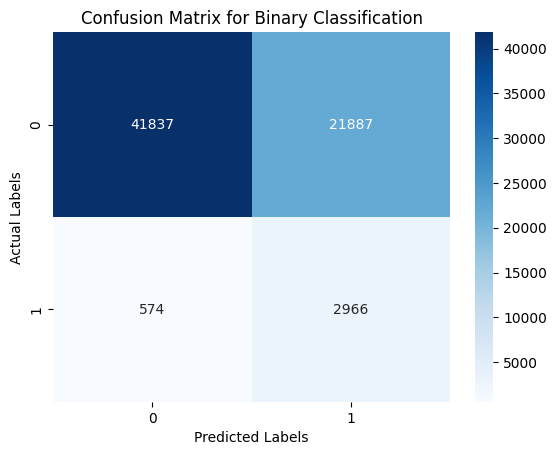

In [13]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [14]:
model.evaluate(test_dataset)

2102/2102 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.6763 - auc: 0.8198 - loss: 0.8827 - precision_1: 0.1308


2024-10-17 17:28:41.599846: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-10-17 17:28:41.599903: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


[0.8948114514350891,
 0.6660769581794739,
 0.8174974918365479,
 0.11934173107147217]